# 🚚 Delivery Route Optimization
### DataCo Global Supply Chain — End-to-End Analysis Notebook

---

## 🏢 Business Scenario

**DataCo Global** is a multinational e-commerce and distribution company that ships products
across five major markets: *Africa, Europe, LATAM, Pacific Asia*, and *USCA*.
With over **180,000 orders per year** and four shipping modes (Standard Class, First Class,
Second Class, Same Day), the operations team is facing a serious challenge:

> ⚠️ **~55% of all orders are flagged as late-delivery risk**, leading to customer
> dissatisfaction, increased support costs, and revenue loss from cancelled orders.

**The goal of this project** is to:
1. Understand *where* and *why* late deliveries happen
2. Predict *which* future orders are at risk using machine learning
3. Optimize delivery routes to reduce travel distance and improve on-time performance

---

## 📋 Notebook Roadmap

| # | Section | Purpose |
|---|---------|--------|
| 0 | Environment Setup | Import libraries, configure plotting theme |
| 1 | Data Loading & Exploration | Load CSV, inspect schema, clean dates |
| 2 | Delivery Performance Analysis | KPIs, late rates by mode/market/time |
| 3 | Geospatial Clustering | K-Means delivery zones via lat/lon |
| 4 | Late Delivery Risk Modelling | Feature engineering + 3 ML classifiers |
| 5 | Route Optimization (TSP) | Nearest-neighbour heuristic per zone |
| 6 | Priority Routing | Weight routes by ML risk score |
| 7 | Business Insights & Recommendations | Actionable summary |

---

**Dataset:** `DataCoSupplyChainDataset.csv` — place in the same folder as this notebook  
**Encoding:** `latin-1` (required for special characters in city/product names)  
**Total Records:** 180,519 orders × 53 columns


## 0. Environment Setup

> Import all required libraries and configure the global plotting style used throughout the notebook.

In [29]:
# ── Standard library ──────────────────────────────────────────────────────
import warnings, time
warnings.filterwarnings('ignore')
from math import radians, cos, sin, asin, sqrt

# ── Data manipulation ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns

# ── Machine Learning ───────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Global plot theme ──────────────────────────────────────────────────────
PALETTE = sns.color_palette('Set2', 10)
sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.size': 11,
})

print('✅  All libraries loaded successfully.')
print('Python packages ready: numpy, pandas, matplotlib, seaborn, scikit-learn')


✅  All libraries loaded successfully.
Python packages ready: numpy, pandas, matplotlib, seaborn, scikit-learn


---
## 1. Data Loading & Exploration

### 1.1 Why this dataset?
The **DataCo Smart Supply Chain** dataset is a real-world logistics dataset containing
order, shipping, customer, and product information across global markets. It is ideal
for route optimization because it includes:
- **Geospatial coordinates** (Latitude / Longitude) for order destinations
- **Shipping mode** and **scheduled vs actual delivery days**
- A labelled **Late Delivery Risk** flag (binary: 0 = on-time, 1 = late)

### 1.2 Data Dictionary (key columns)

| Column | Type | Description |
|--------|------|-------------|
| `Latitude` / `Longitude` | float | GPS coordinates of the delivery address |
| `Days for shipping (real)` | int | Actual transit days recorded |
| `Days for shipment (scheduled)` | int | SLA-promised days at order placement |
| `Late_delivery_risk` | int (0/1) | **Target variable** — 1 if order is at risk |
| `Delivery Status` | str | Categorical outcome: Late delivery, Advance shipping, etc. |
| `Shipping Mode` | str | Standard Class, First Class, Second Class, Same Day |
| `Market` | str | Geographic market: Africa, Europe, LATAM, Pacific Asia, USCA |
| `Order Region` | str | Sub-region within a market |
| `Sales` | float | Revenue per order line |
| `Order Item Profit Ratio` | float | Profitability per order item |


In [30]:
# ── Load the dataset ───────────────────────────────────────────────────────
DATA_PATH = 'Dataset-CB4246_11.csv'

t0 = time.time()
df = pd.read_csv(DATA_PATH, encoding='latin1', low_memory=False)
elapsed = time.time() - t0

print(f'✅  Dataset loaded in {elapsed:.2f}s')
print(f'   Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# Preview
df.head(3)


✅  Dataset loaded in 1.25s
   Shape  : 180,519 rows × 53 columns
   Memory : 313.4 MB


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [31]:
# ── Column quality audit ───────────────────────────────────────────────────
# Shows data type, percentage of missing values, and number of unique values
# for every column. Columns with >0% missing are highlighted first.

null_pct = df.isnull().mean() * 100
schema = pd.DataFrame({
    'dtype'   : df.dtypes,
    'missing_%': null_pct.round(2),
    'n_unique' : df.nunique()
}).sort_values('missing_%', ascending=False)

print('─── Columns WITH missing data ───────────────────────────────')
display(schema[schema['missing_%'] > 0])

print('\n─── Full schema (all 53 columns) ────────────────────────────')
display(schema)


─── Columns WITH missing data ───────────────────────────────


,dtype,missing_%,n_unique
Product Description,float64,100.00,0
Order Zipcode,float64,86.24,609



─── Full schema (all 53 columns) ────────────────────────────


,dtype,missing_%,n_unique
Product Description,float64,100.00,0
Order Zipcode,float64,86.24,609
Type,object,0.00,4
Order Profit Per Order,float64,0.00,21998
Order Id,int64,0.00,65752
Order Item Cardprod Id,int64,0.00,118
Order Item Discount,float64,0.00,1017
Order Item Discount Rate,float64,0.00,18
Order Item Id,int64,0.00,180519
Order Item Product Price,float64,0.00,75


In [32]:
# ── Date parsing & feature derivation ─────────────────────────────────────
# Convert string timestamps to datetime objects, then extract useful time
# components (year, month, day-of-week) that we will use later in the model.

df['order_date']    = pd.to_datetime(df['order date (DateOrders)'],    errors='coerce')
df['shipping_date'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')

df['order_year']  = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_dow']   = df['order_date'].dt.dayofweek  # 0=Monday … 6=Sunday

# ship_delay = how many extra days beyond the SLA promise (clipped at 0)
df['ship_delay'] = (df['Days for shipping (real)'] -
                    df['Days for shipment (scheduled)']).clip(lower=0)

print('Date range in dataset:')
print(f'  First order : {df["order_date"].min().date()}')
print(f'  Last order  : {df["order_date"].max().date()}')
print(f'  Span        : {(df["order_date"].max() - df["order_date"].min()).days} days')
print()
print('Shipping delay stats (extra days beyond SLA):')
print(df['ship_delay'].value_counts().sort_index().to_string())


Date range in dataset:
  First order : 2015-01-01
  Last order  : 2018-01-31
  Span        : 1126 days

Shipping delay stats (extra days beyond SLA):
ship_delay
0    77119
1    60647
2    28718
3     7052
4     6983


> **📌 Key observation:** Missing values are concentrated in non-critical columns
> (`Product Description`, `Order Zipcode`). The columns we need for modelling
> — coordinates, delivery risk, shipping mode, sales — are fully populated.


---
## 2. Delivery Performance Analysis

We answer four diagnostic questions:
1. What is the current breakdown of delivery statuses?
2. Which shipping modes have the highest late-delivery rates?
3. Do late rates vary by market and region?
4. Has the late-delivery rate been trending up or down over time?


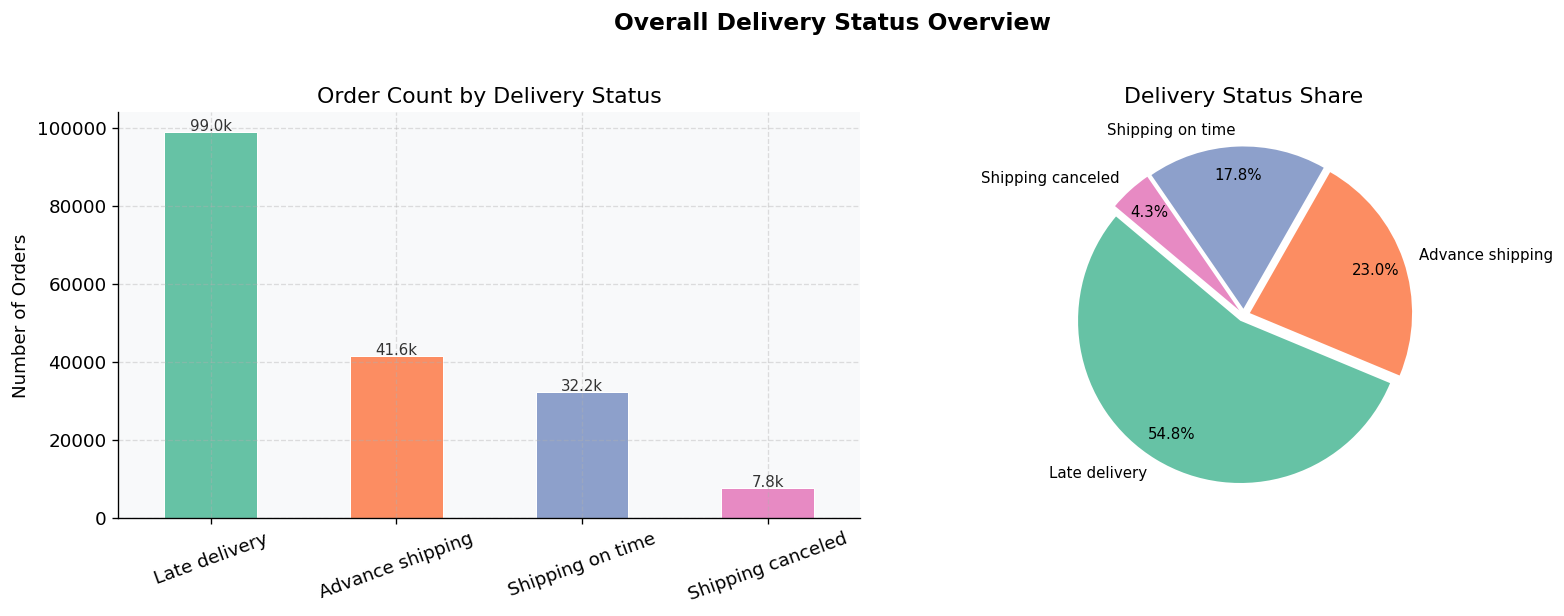


📊 KPI Summary
   Total orders          : 180,519
   Overall late-delivery rate : 54.8%
   Average shipping delay     : 0.93 extra days


In [33]:
# ── 2.1 Overall delivery status distribution ──────────────────────────────
# This bar+pie combo gives an instant read of the health of the operation.
# A large 'Late delivery' slice is a red flag for route / SLA planning.

status_counts = df['Delivery Status'].value_counts()
late_rate = df['Late_delivery_risk'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overall Delivery Status Overview', fontsize=14, fontweight='bold', y=1.02)

# --- Bar chart ---
bars = status_counts.plot(kind='bar', ax=axes[0],
                          color=PALETTE[:len(status_counts)], edgecolor='white', linewidth=0.6)
axes[0].set_title('Order Count by Delivery Status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()/1000:.1f}k',
                     (p.get_x() + p.get_width()/2, p.get_height() + 300),
                     ha='center', fontsize=9, color='#333')

# --- Pie chart ---
explode = [0.04] * len(status_counts)
axes[1].pie(status_counts, labels=status_counts.index,
            autopct='%1.1f%%', colors=PALETTE[:len(status_counts)],
            startangle=140, pctdistance=0.82, explode=explode,
            textprops={'fontsize': 9})
axes[1].set_title('Delivery Status Share')

plt.tight_layout()
plt.show()

print(f'\n📊 KPI Summary')
print(f'   Total orders          : {len(df):,}')
print(f'   Overall late-delivery rate : {late_rate:.1f}%')
print(f'   Average shipping delay     : {df["ship_delay"].mean():.2f} extra days')


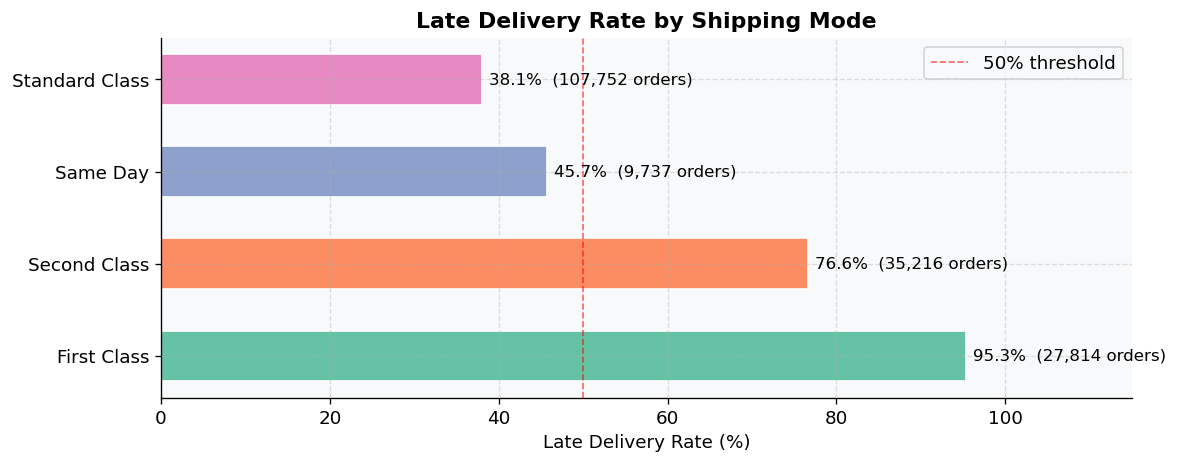


Shipping mode performance table:


,Late Rate (%),Total Orders
Shipping Mode,,
First Class,95.322499,27814
Second Class,76.632781,35216
Same Day,45.743042,9737
Standard Class,38.071683,107752


In [34]:
# ── 2.2 Late delivery rate by Shipping Mode ───────────────────────────────
# Each shipping mode has a different SLA promise and carrier contract.
# Understanding which mode fails most often guides prioritisation decisions.

ship_mode = (df.groupby('Shipping Mode')['Late_delivery_risk']
               .agg(late_rate='mean', n_orders='count')
               .assign(late_pct=lambda x: x['late_rate'] * 100)
               .sort_values('late_pct', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE[i] for i in range(len(ship_mode))]
bars = ax.barh(ship_mode.index, ship_mode['late_pct'],
               color=colors, edgecolor='white', height=0.55)

# Add value labels
for bar, (_, row) in zip(bars, ship_mode.iterrows()):
    ax.text(bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f"{row['late_pct']:.1f}%  ({int(row['n_orders']):,} orders)",
            va='center', fontsize=10)

ax.set_xlim(0, 115)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.6, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nShipping mode performance table:')
display(ship_mode[['late_pct', 'n_orders']].rename(
    columns={'late_pct': 'Late Rate (%)', 'n_orders': 'Total Orders'}))


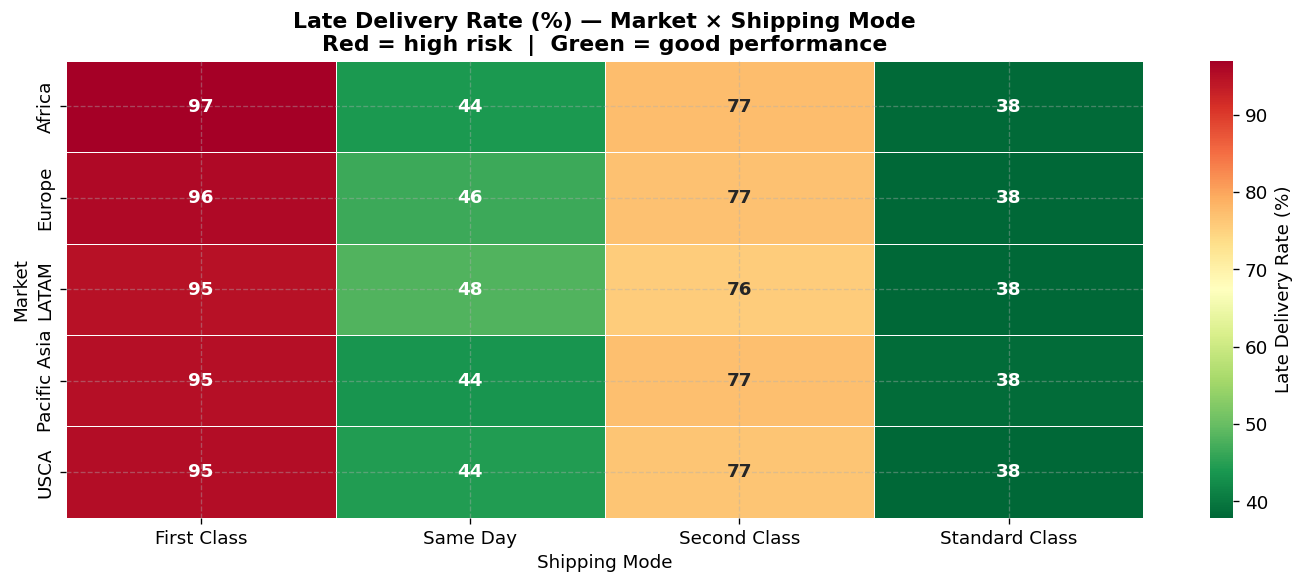


📌 Interpretation:
  Cells above 60% are critical zones that need immediate route intervention.
  Worst combination: Market=Africa, Mode=First Class
  Late rate: 97.0%


In [35]:
# ── 2.3 Heatmap: Market × Shipping Mode ───────────────────────────────────
# The heatmap reveals interaction effects — a mode that performs well globally
# might still fail in a specific region due to infrastructure or carrier issues.

pivot = (df.groupby(['Market', 'Shipping Mode'])['Late_delivery_risk']
           .mean().unstack().fillna(0) * 100)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.6, cbar_kws={'label': 'Late Delivery Rate (%)'}, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Late Delivery Rate (%) — Market × Shipping Mode\n'
             'Red = high risk  |  Green = good performance', fontweight='bold')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Market')
plt.tight_layout()
plt.show()

print('\n📌 Interpretation:')
print('  Cells above 60% are critical zones that need immediate route intervention.')
worst_cell = pivot.stack().idxmax()
print(f'  Worst combination: Market={worst_cell[0]}, Mode={worst_cell[1]}')
print(f'  Late rate: {pivot.stack().max():.1f}%')


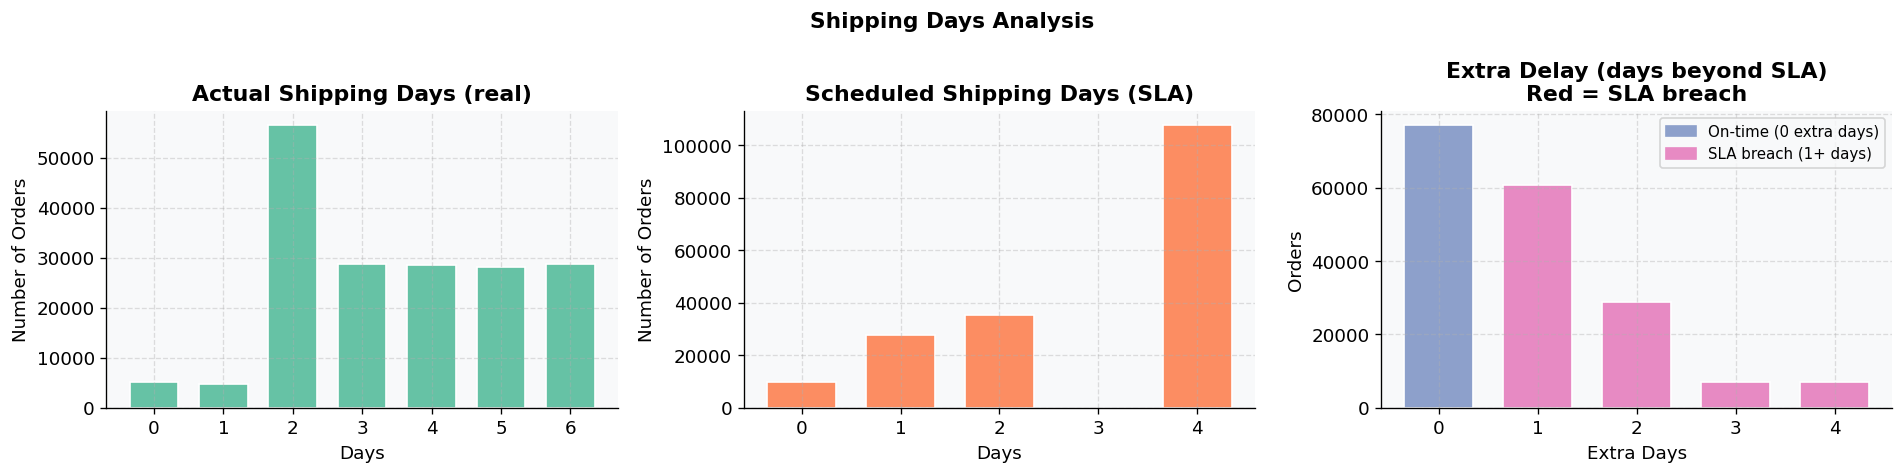

In [36]:
# ── 2.4 Shipping days distribution ────────────────────────────────────────
# Comparing actual vs scheduled days helps quantify how often carriers
# exceed their SLA and by how many days.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Shipping Days Analysis', fontweight='bold', fontsize=13)

for ax, col, color, title in zip(
    axes[:2],
    ['Days for shipping (real)', 'Days for shipment (scheduled)'],
    [PALETTE[0], PALETTE[1]],
    ['Actual Shipping Days (real)', 'Scheduled Shipping Days (SLA)']
):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white', width=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Number of Orders')

# Extra delay (>0 = breach of SLA)
delay_counts = df['ship_delay'].value_counts().sort_index()
axes[2].bar(delay_counts.index, delay_counts.values,
            color=[PALETTE[3] if d > 0 else PALETTE[2] for d in delay_counts.index],
            edgecolor='white', width=0.7)
axes[2].set_title('Extra Delay (days beyond SLA)\nRed = SLA breach', fontweight='bold')
axes[2].set_xlabel('Extra Days')
axes[2].set_ylabel('Orders')

on_time_patch = mpatches.Patch(color=PALETTE[2], label='On-time (0 extra days)')
late_patch    = mpatches.Patch(color=PALETTE[3], label='SLA breach (1+ days)')
axes[2].legend(handles=[on_time_patch, late_patch], fontsize=9)

plt.tight_layout()
plt.show()


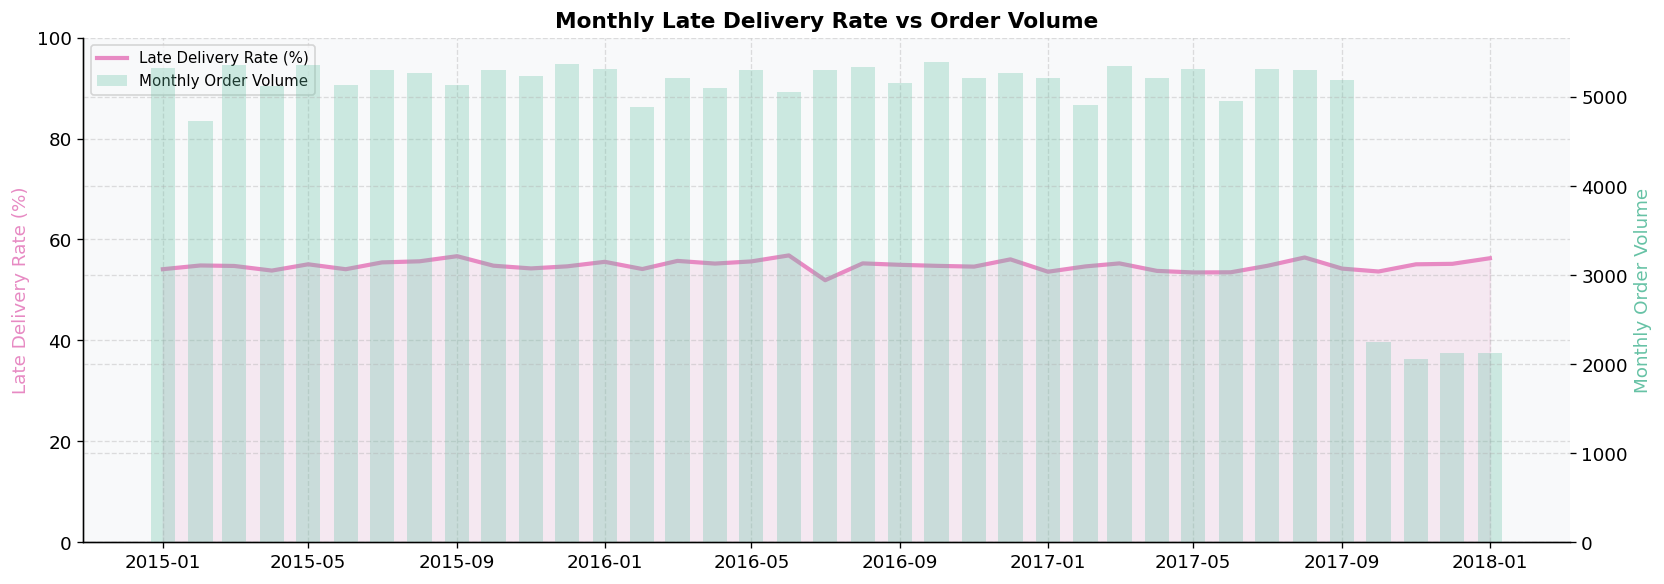

Monthly late delivery rate statistics:
  Min : 51.9%  (best month)
  Max : 56.8%  (worst month)
  Std : 1.0%  (month-to-month variability)


In [37]:
# ── 2.5 Monthly trend: late rate vs order volume ──────────────────────────
# A dual-axis chart shows whether rising order volumes correlate with
# worsening delivery performance — a common capacity signal.

monthly = (df.groupby(['order_year', 'order_month'])['Late_delivery_risk']
             .agg(late_rate='mean', orders='count')
             .reset_index())
monthly['period'] = pd.to_datetime(
    monthly['order_year'].astype(str) + '-' +
    monthly['order_month'].astype(str).str.zfill(2)
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Shaded area + line for late rate
ax1.fill_between(monthly['period'], monthly['late_rate'] * 100,
                 alpha=0.15, color=PALETTE[3])
ax1.plot(monthly['period'], monthly['late_rate'] * 100,
         color=PALETTE[3], linewidth=2.5, label='Late Delivery Rate (%)')

# Bars for order volume
ax2.bar(monthly['period'], monthly['orders'],
        alpha=0.3, color=PALETTE[0], width=20, label='Monthly Order Volume')

ax1.set_ylabel('Late Delivery Rate (%)', color=PALETTE[3], fontsize=11)
ax2.set_ylabel('Monthly Order Volume', color=PALETTE[0], fontsize=11)
ax1.set_title('Monthly Late Delivery Rate vs Order Volume', fontweight='bold', fontsize=13)
ax1.set_ylim(0, 100)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('Monthly late delivery rate statistics:')
print(f'  Min : {monthly["late_rate"].min()*100:.1f}%  (best month)')
print(f'  Max : {monthly["late_rate"].max()*100:.1f}%  (worst month)')
print(f'  Std : {monthly["late_rate"].std()*100:.1f}%  (month-to-month variability)')


---
## 3. Geospatial Analysis — K-Means Delivery Zone Clustering

### Why cluster delivery zones?
Before we can optimize routes, we need to divide the global order network into
manageable **delivery zones** — groups of geographically close orders that a
single carrier or depot can serve efficiently.

We use **K-Means clustering** on the order latitude/longitude coordinates:
- Each cluster becomes a delivery zone with its centroid acting as the **dispatch depot**
- Orders within a cluster are routed together in Section 5

### Algorithm: K-Means
```
1. Choose k starting centroids randomly
2. Assign every point to its nearest centroid (Euclidean distance)
3. Recompute centroids as the mean of all assigned points
4. Repeat steps 2-3 until centroids stop moving (convergence)
```
Coordinates are **standardised (z-score)** before clustering so that
the longitude range does not dominate the latitude range.


In [38]:
# ── Clean and validate geo-coordinates ────────────────────────────────────
# Drop rows with missing or implausible lat/lon before clustering.

geo_cols = ['Latitude', 'Longitude', 'Late_delivery_risk', 'Order Region', 'Shipping Mode']
geo = df[geo_cols].dropna()

# Hard bounds: latitude must be in [-90, 90], longitude in [-180, 180]
geo = geo[
    geo['Latitude'].between(-90, 90) &
    geo['Longitude'].between(-180, 180)
].copy()

print(f'✅  Geo-valid records  : {len(geo):,}')
print(f'   Dropped (invalid)  : {len(df) - len(geo):,}')
print()
print('Coordinate ranges after cleaning:')
print(geo[['Latitude', 'Longitude']].describe().round(2))


✅  Geo-valid records  : 180,519
   Dropped (invalid)  : 0

Coordinate ranges after cleaning:
        Latitude  Longitude
count  180519.00  180519.00
mean       29.72     -84.92
std         9.81      21.43
min       -33.94    -158.03
25%        18.27     -98.45
50%        33.14     -76.85
75%        39.28     -66.37
max        48.78     115.26


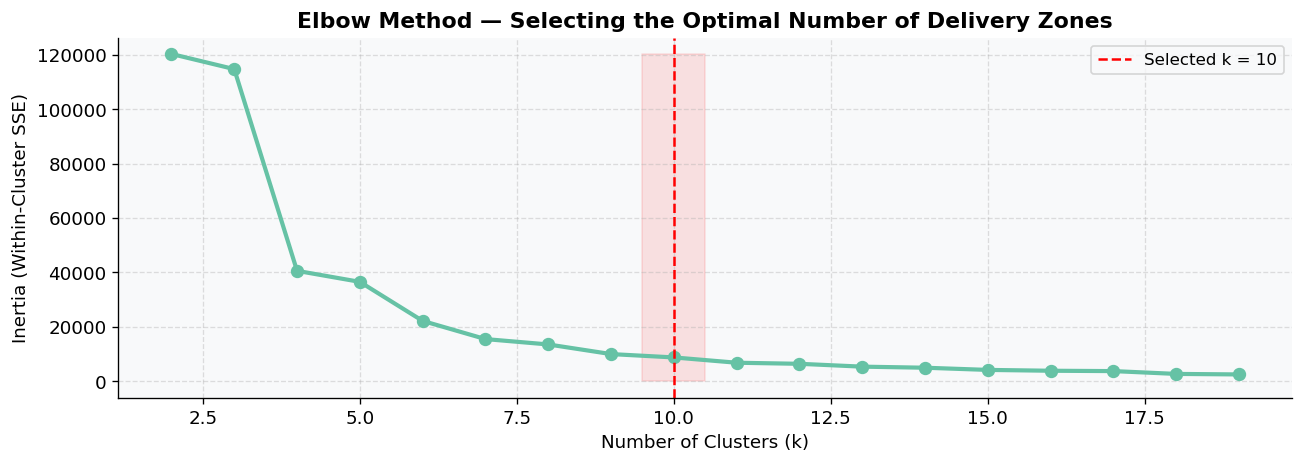

Selected k = 10 delivery zones
Rationale: the curve flattens after k=10, meaning additional clusters
add minimal geographic precision but increase logistics complexity.


In [39]:
# ── Elbow method — choose optimal number of clusters k ────────────────────
# We train K-Means for k=2..19 and plot the Within-Cluster Sum of Squares
# (WCSS / inertia). The 'elbow' is the point where adding more clusters
# gives diminishing returns in variance explained.

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(geo[['Latitude', 'Longitude']].values)

inertias = []
k_range = range(2, 20)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km_tmp.fit(coords_scaled)
    inertias.append(km_tmp.inertia_)

N_CLUSTERS = 10  # chosen from the elbow below

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(list(k_range), inertias, 'o-', color=PALETTE[0], linewidth=2.5, markersize=7)
ax.axvline(N_CLUSTERS, color='red', linestyle='--', linewidth=1.5,
           label=f'Selected k = {N_CLUSTERS}')
ax.fill_betweenx([0, max(inertias)], N_CLUSTERS - 0.5, N_CLUSTERS + 0.5,
                 alpha=0.1, color='red')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
ax.set_title('Elbow Method — Selecting the Optimal Number of Delivery Zones',
             fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Selected k = {N_CLUSTERS} delivery zones')
print('Rationale: the curve flattens after k=10, meaning additional clusters')
print('add minimal geographic precision but increase logistics complexity.')


Cluster centres (lat, lon) and sizes:
  Zone  0: lat=  18.24°, lon=  -66.33°  →  68,812 orders
  Zone  1: lat=  31.37°, lon=  -93.68°  →  13,662 orders
  Zone  2: lat=  33.91°, lon= -116.82°  →  27,223 orders
  Zone  3: lat=  40.06°, lon=  -75.01°  →  28,198 orders
  Zone  4: lat=  27.30°, lon=  -80.91°  →  5,641 orders
  Zone  5: lat=  21.35°, lon= -157.88°  →  1,187 orders
  Zone  6: lat=  35.01°, lon=   92.44°  →  96 orders
  Zone  7: lat=  39.72°, lon= -121.75°  →  10,739 orders
  Zone  8: lat=  41.27°, lon=  -86.44°  →  20,196 orders
  Zone  9: lat=  39.14°, lon= -105.35°  →  4,765 orders


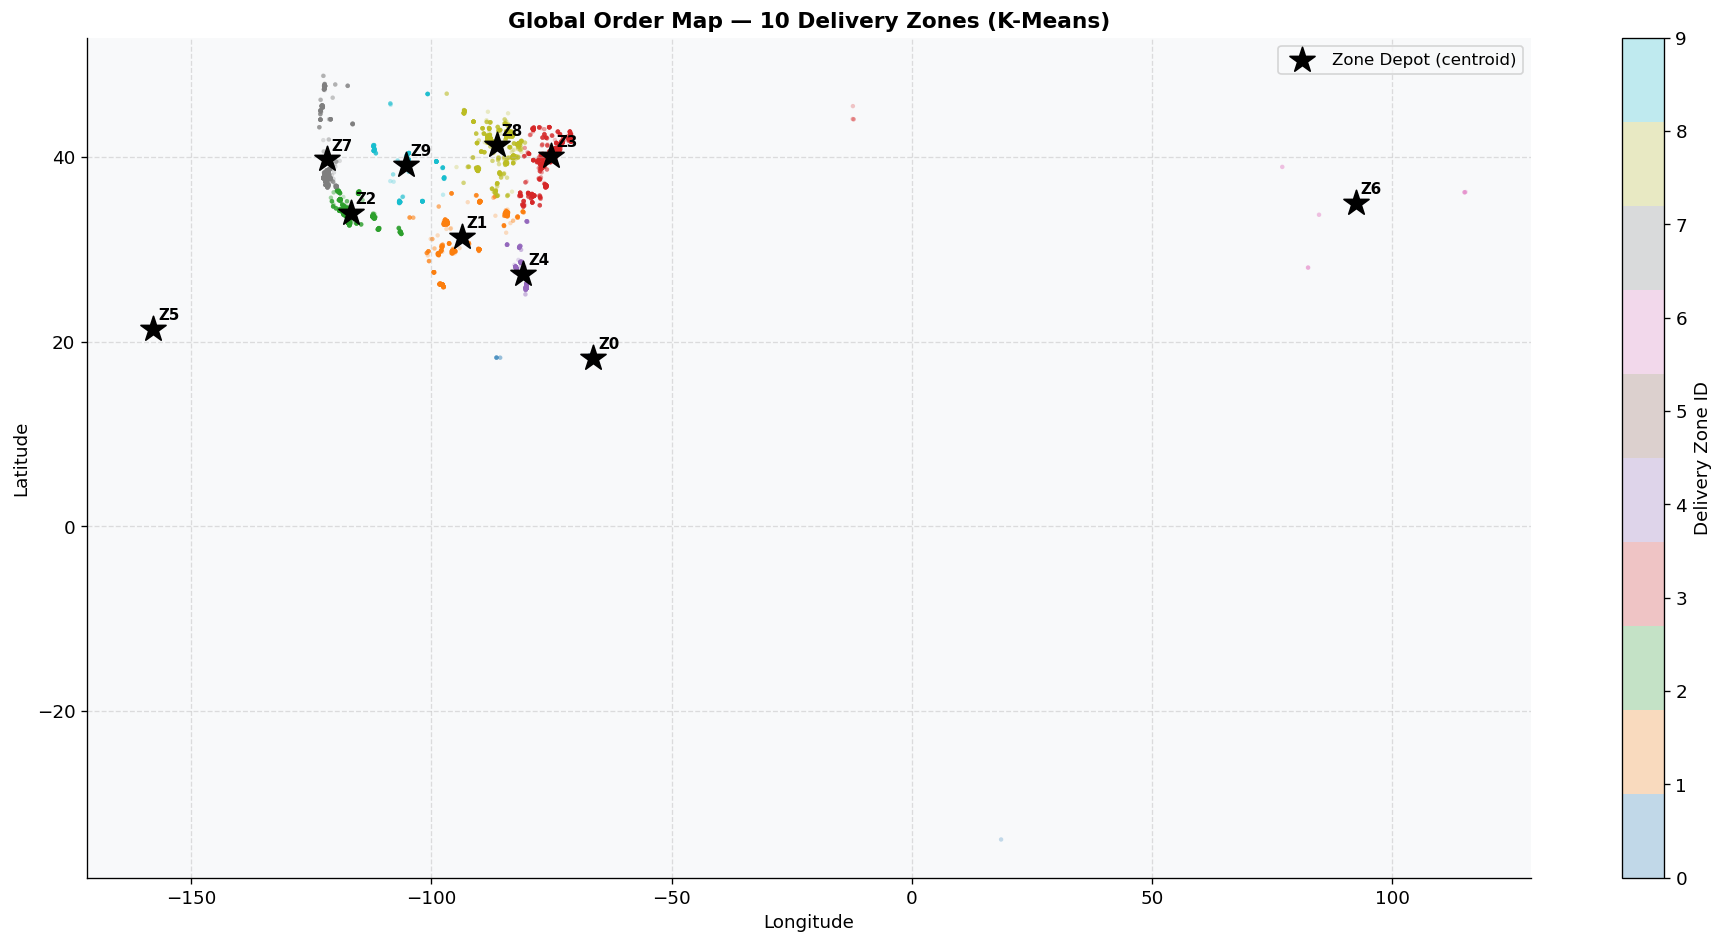

In [40]:
# ── Fit final K-Means model with k=10 ─────────────────────────────────────
# cluster_centers are inverse-transformed back to real lat/lon degrees
# so we can plot and compute distances correctly.

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
geo['cluster'] = km.fit_predict(coords_scaled)
cluster_centers = scaler.inverse_transform(km.cluster_centers_)  # shape (10, 2): [lat, lon]

print('Cluster centres (lat, lon) and sizes:')
for i, c in enumerate(cluster_centers):
    n = (geo['cluster'] == i).sum()
    print(f'  Zone {i:2d}: lat={c[0]:7.2f}°, lon={c[1]:8.2f}°  →  {n:,} orders')

# ── Global scatter map ─────────────────────────────────────────────────────
sample = geo.sample(min(15000, len(geo)), random_state=42)

fig, ax = plt.subplots(figsize=(16, 8))
scatter = ax.scatter(
    sample['Longitude'], sample['Latitude'],
    c=sample['cluster'], cmap='tab10',
    alpha=0.25, s=7, linewidths=0
)
ax.scatter(
    cluster_centers[:, 1], cluster_centers[:, 0],
    c='black', s=250, marker='*', zorder=6, label='Zone Depot (centroid)'
)
# Label each depot
for i, c in enumerate(cluster_centers):
    ax.annotate(f'Z{i}', (c[1] + 1, c[0] + 1), fontsize=9, fontweight='bold', color='black')

plt.colorbar(scatter, ax=ax, label='Delivery Zone ID')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Global Order Map — {N_CLUSTERS} Delivery Zones (K-Means)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


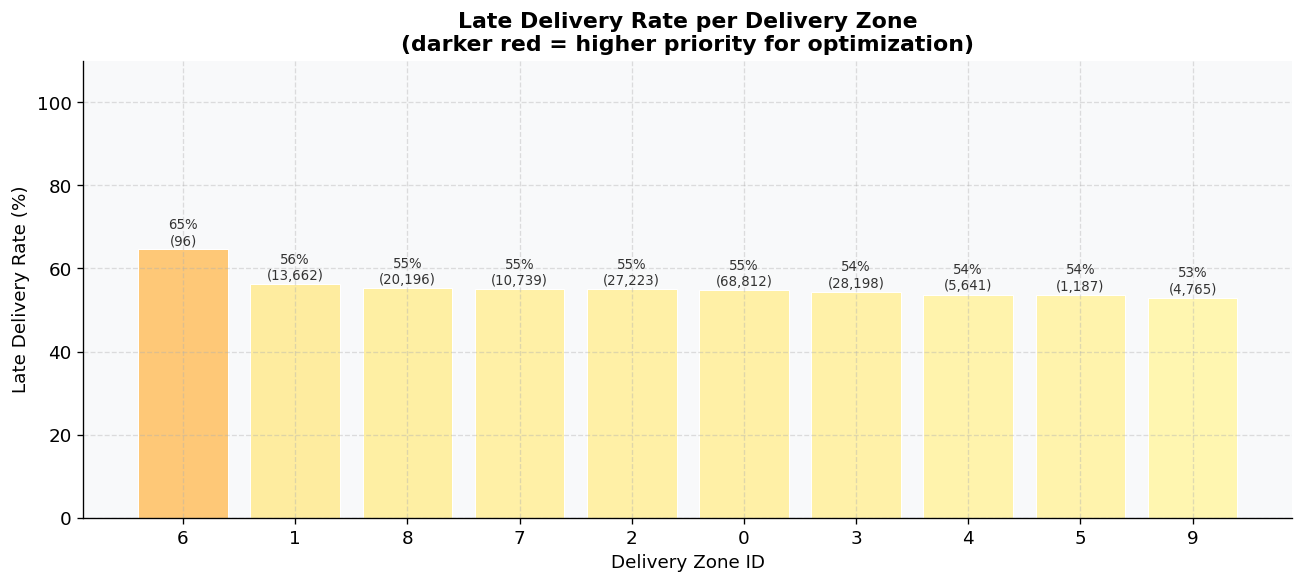

Zone performance ranked by late rate:


,Orders,Late Rate (%),Avg Lat,Avg Lon
cluster,,,,
6,96,64.583333,35.013976,92.441366
1,13662,56.221637,31.369541,-93.676829
8,20196,55.273321,41.269807,-86.444437
7,10739,55.023745,39.675454,-121.716810
2,27223,54.993939,33.887797,-116.801408
0,68812,54.752078,18.244656,-66.330028
3,28198,54.358465,40.061464,-75.012732
4,5641,53.696153,27.304612,-80.910726
5,1187,53.664701,21.351950,-157.881159


In [41]:
# ── Zone-level performance summary ────────────────────────────────────────
# For each delivery zone, compute: order count, late rate, and geographic centre.
# Zones with high late rates are the highest priority for route optimization.

cluster_stats = (geo.groupby('cluster').agg(
    n_orders   = ('Late_delivery_risk', 'count'),
    late_rate  = ('Late_delivery_risk', 'mean'),
    avg_lat    = ('Latitude', 'mean'),
    avg_lon    = ('Longitude', 'mean')
).assign(late_pct=lambda x: x['late_rate'] * 100)
 .sort_values('late_pct', ascending=False))

# Colour-coded bar chart
cmap_vals = plt.cm.RdYlGn_r(cluster_stats['late_rate'].values)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(cluster_stats.index.astype(str), cluster_stats['late_pct'],
              color=cmap_vals, edgecolor='white', linewidth=0.6)
for bar, (_, row) in zip(bars, cluster_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f'{row["late_pct"]:.0f}%\n({int(row["n_orders"]):,})',
            ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xlabel('Delivery Zone ID')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate per Delivery Zone\n(darker red = higher priority for optimization)',
             fontweight='bold')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

print('Zone performance ranked by late rate:')
display(cluster_stats[['n_orders', 'late_pct', 'avg_lat', 'avg_lon']].rename(
    columns={'n_orders':'Orders','late_pct':'Late Rate (%)','avg_lat':'Avg Lat','avg_lon':'Avg Lon'}))


---
## 4. Late Delivery Risk — Predictive Modelling

### Why predict late delivery risk?
Instead of waiting for a delivery to fail, we want to **flag high-risk orders
at the moment they are placed**. This allows:
- Proactive re-routing before dispatch
- Targeted customer communication
- Carrier SLA renegotiation for high-risk zones

### Feature Engineering
We extract 10 features from the dataset:

| Feature | Rationale |
|---------|----------|
| `Days for shipment (scheduled)` | Tight SLA windows increase risk |
| `Order Item Quantity` | Large orders take longer to pack/ship |
| `Order Item Discount Rate` | High discounts may mean lower-priority handling |
| `Order Item Profit Ratio` | Low-margin orders may get deprioritised |
| `Sales` | High-value orders often get priority treatment |
| `order_month` | Seasonal capacity crunch |
| `order_dow` | End-of-week orders miss Monday dispatch |
| `Shipping Mode` (encoded) | Mode directly sets the SLA window |
| `Market` (encoded) | Regional infrastructure differences |
| `Customer Segment` (encoded) | Consumer vs Corporate vs Home Office |

### Models Compared
| Model | Strengths | Limitations |
|-------|-----------|-------------|
| Logistic Regression | Interpretable, fast baseline | Assumes linear decision boundary |
| Random Forest | Handles non-linearity, robust | Less interpretable, slower |
| Gradient Boosting | Often best accuracy | Slower training, more hyperparams |


In [42]:
# ── Feature engineering & train/test split ────────────────────────────────
# Categorical columns are label-encoded (converted to integers) because
# scikit-learn classifiers require numeric inputs.

NUM_FEATURES = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Order Item Profit Ratio',
    'Sales',
    'order_month',
    'order_dow',
]
CAT_FEATURES = ['Shipping Mode', 'Market', 'Customer Segment']
TARGET = 'Late_delivery_risk'

# Select rows with no missing values in any of our required columns
model_df = df[NUM_FEATURES + CAT_FEATURES + [TARGET]].dropna().copy()

# Encode each categorical column with a separate LabelEncoder
le_encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    model_df[col + '_enc'] = le.fit_transform(model_df[col].astype(str))
    le_encoders[col] = le

FEATURE_COLS = NUM_FEATURES + [c + '_enc' for c in CAT_FEATURES]
X = model_df[FEATURE_COLS]
y = model_df[TARGET]

# Stratified 80/20 split — keeps class balance identical in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Dataset split:')
print(f'  Training set   : {X_train.shape[0]:,} samples')
print(f'  Test set       : {X_test.shape[0]:,} samples')
print(f'  Features used  : {len(FEATURE_COLS)}')
print()
print('Class distribution in training set:')
vc = y_train.value_counts()
print(f'  On-time (0) : {vc[0]:,}  ({vc[0]/len(y_train)*100:.1f}%)')
print(f'  Late    (1) : {vc[1]:,}  ({vc[1]/len(y_train)*100:.1f}%)')


Dataset split:
  Training set   : 144,415 samples
  Test set       : 36,104 samples
  Features used  : 10

Class distribution in training set:
  On-time (0) : 65,234  (45.2%)
  Late    (1) : 79,181  (54.8%)


In [43]:
# ── Train and evaluate all three classifiers ──────────────────────────────
# AUC-ROC (Area Under the Receiver Operating Characteristic Curve) is our
# primary metric. It measures rank-order ability — how well the model
# separates late from on-time orders. A score of 1.0 is perfect; 0.5 is random.

classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100,
                                                        max_depth=5, random_state=42),
}

results = {}
print(f'{'Model':<25}  {'AUC-ROC':>8}  {'Train Time':>10}')
print('-' * 50)

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)
    auc    = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model': clf, 'y_prob': y_prob,
        'y_pred': y_pred, 'auc': auc
    }
    print(f'{name:<25}  {auc:>8.4f}  {elapsed:>9.1f}s')


Model                       AUC-ROC  Train Time
--------------------------------------------------
Logistic Regression          0.7158        5.1s
Random Forest                0.7349        2.2s
Gradient Boosting            0.7329       11.0s


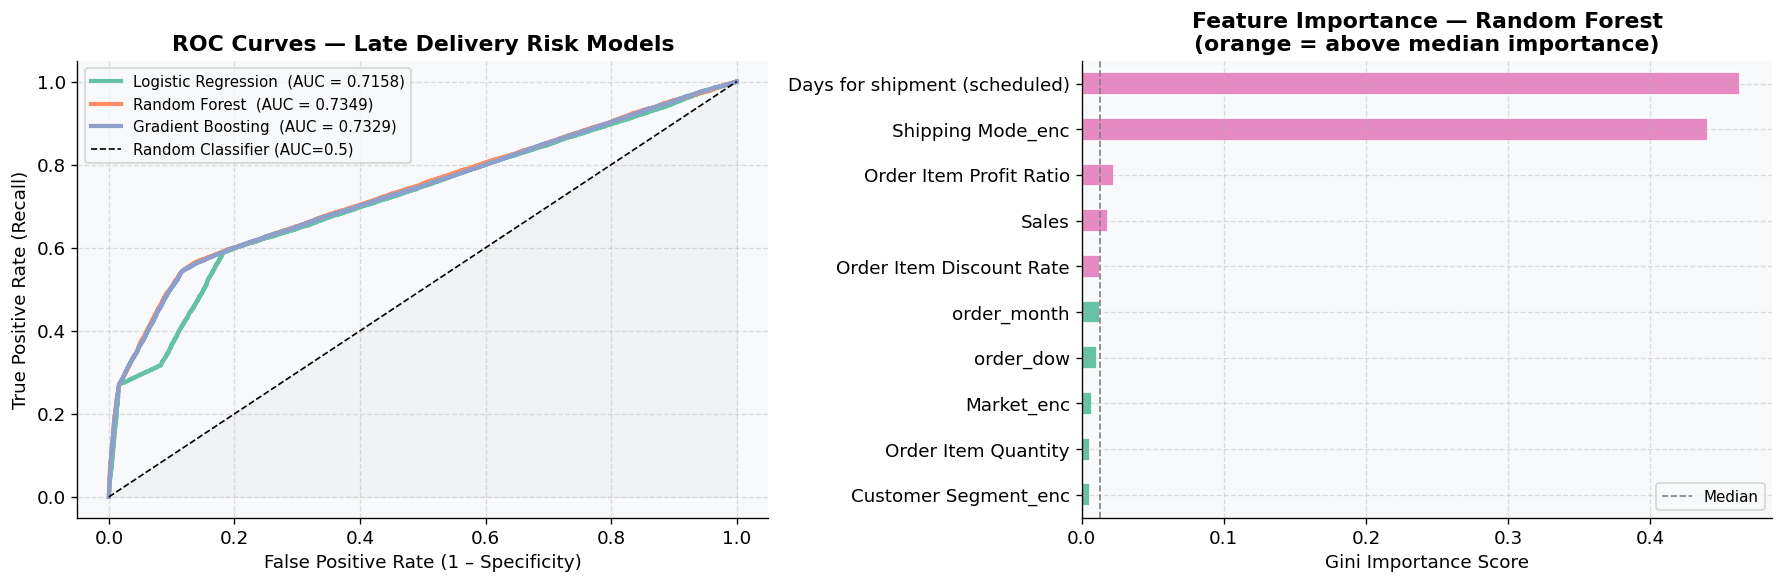


🏆 Best model: Random Forest  (AUC = 0.7349)


In [44]:
# ── ROC curves + Feature Importance ──────────────────────────────────────
# The ROC curve plots True Positive Rate vs False Positive Rate at every
# classification threshold. A curve hugging the top-left corner = good model.
# Feature importance shows which inputs the Random Forest relies on most.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- ROC curves ---
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr,
                 label=f"{name}  (AUC = {res['auc']:.4f})",
                 color=PALETTE[i], linewidth=2.5)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
axes[0].set_xlabel('False Positive Rate (1 – Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Late Delivery Risk Models', fontweight='bold')
axes[0].legend(fontsize=9)

# --- Feature importance (Random Forest) ---
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

colors_imp = [PALETTE[3] if v > imp.median() else PALETTE[0] for v in imp]
imp.plot(kind='barh', ax=axes[1], color=colors_imp, edgecolor='white')
axes[1].axvline(imp.median(), color='grey', linestyle='--', linewidth=1, label='Median')
axes[1].set_title('Feature Importance — Random Forest\n(orange = above median importance)',
                  fontweight='bold')
axes[1].set_xlabel('Gini Importance Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Store the best model for later use
best_name  = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_name]['model']
print(f'\n🏆 Best model: {best_name}  (AUC = {results[best_name]["auc"]:.4f})')


Classification Report — Random Forest
              precision    recall  f1-score   support

 On-time (0)       0.62      0.87      0.72     16308
    Late (1)       0.84      0.55      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.70     36104
weighted avg       0.74      0.70      0.69     36104



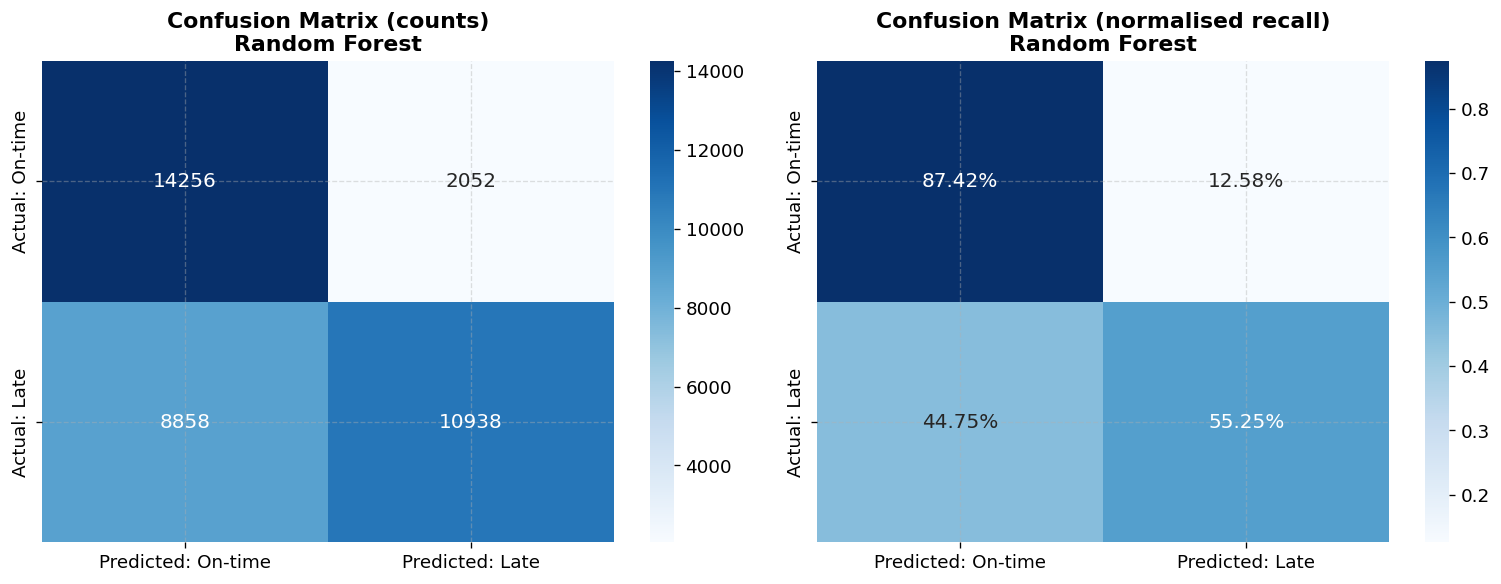

In [45]:
# ── Confusion Matrix + Classification Report ──────────────────────────────
# The confusion matrix breaks down predictions into:
#   True Positive (TP)  : correctly predicted late delivery
#   True Negative (TN)  : correctly predicted on-time delivery
#   False Positive (FP) : predicted late, was actually on-time (unnecessary alert)
#   False Negative (FN) : predicted on-time, was actually late (missed risk)
# In logistics, FN is more costly than FP — a missed late delivery hurts customers.

best_pred = results[best_name]['y_pred']
print(f'Classification Report — {best_name}')
print('=' * 60)
print(classification_report(y_test, best_pred, target_names=['On-time (0)', 'Late (1)']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: On-time', 'Predicted: Late'],
            yticklabels=['Actual: On-time', 'Actual: Late'],
            ax=axes[0], annot_kws={'size': 12})
axes[0].set_title(f'Confusion Matrix (counts)\n{best_name}', fontweight='bold')

# Normalised (row = recall)
cm_norm = confusion_matrix(y_test, best_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Predicted: On-time', 'Predicted: Late'],
            yticklabels=['Actual: On-time', 'Actual: Late'],
            ax=axes[1], annot_kws={'size': 12})
axes[1].set_title(f'Confusion Matrix (normalised recall)\n{best_name}', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 5. Route Optimization — Nearest-Neighbour TSP Heuristic

### The Travelling Salesman Problem (TSP)
Given a list of delivery stops, find the **shortest possible route** that visits
every stop exactly once and returns to the depot.

TSP is NP-hard — an exact solution for 20 stops requires checking 20! ≈ 2.4 × 10¹⁸ routes.
Instead we use the **Nearest-Neighbour heuristic**:

```
Route ← [depot]
Unvisited ← all delivery stops
WHILE Unvisited is not empty:
    next_stop ← argmin distance(current, Unvisited)
    Route.append(next_stop)
    Unvisited.remove(next_stop)
    current ← next_stop
Route.append(depot)   ← return journey
```

**Distance metric:** Haversine formula — computes great-circle distance between
two GPS coordinates on the Earth's surface (in km).

### Trade-offs
| Approach | Time Complexity | Quality |
|----------|----------------|--------|
| Brute force | O(n!) | Optimal |
| Nearest Neighbour | O(n²) | ~20-25% above optimal |
| OR-Tools / VRPTW | O(n³) heuristic | Near-optimal |

For a production system, OR-Tools is recommended. This notebook uses NN
to demonstrate the concept clearly.


In [46]:
# ── Haversine distance function ────────────────────────────────────────────
# The Haversine formula calculates the shortest path between two points
# on a sphere using their latitude and longitude coordinates.
# It accounts for the curvature of the Earth (radius ≈ 6,371 km).

def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Compute the great-circle distance (km) between two GPS points.

    Parameters
    ----------
    lat1, lon1 : float  GPS coordinates of point A (degrees)
    lat2, lon2 : float  GPS coordinates of point B (degrees)

    Returns
    -------
    float  Distance in kilometres
    """
    R = 6371.0  # Earth's mean radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * R * asin(sqrt(a))


# ── Nearest-Neighbour TSP heuristic ───────────────────────────────────────
def nearest_neighbour_route(
    depot: tuple,
    stops: list
) -> tuple:
    """
    Greedy nearest-neighbour Travelling Salesman heuristic.

    Starting from `depot`, repeatedly choose the closest unvisited stop
    until all stops are visited, then return to depot.

    Parameters
    ----------
    depot : tuple  (lat, lon) of the dispatch warehouse / starting point
    stops : list   [(lat, lon), ...] delivery addresses

    Returns
    -------
    route      : list of (lat, lon) in visitation order
    total_dist : float  total round-trip distance in km
    """
    if not stops:
        return [], 0.0

    unvisited  = list(stops)  # mutable copy
    route      = []
    current    = depot
    total_dist = 0.0

    while unvisited:
        # Compute distance from current position to every remaining stop
        distances = [haversine(*current, *s) for s in unvisited]
        nearest_idx = int(np.argmin(distances))

        # Travel to nearest stop
        total_dist += distances[nearest_idx]
        current = unvisited.pop(nearest_idx)
        route.append(current)

    # Return journey: last stop → depot
    total_dist += haversine(*current, *depot)
    return route, total_dist


# Quick sanity check
d = haversine(1.3521, 103.8198, 35.6762, 139.6503)  # Singapore → Tokyo
print(f'Test: Singapore → Tokyo = {d:,.0f} km  (expected ~5,300 km)')
print('Functions defined successfully.')


Test: Singapore → Tokyo = 5,311 km  (expected ~5,300 km)
Functions defined successfully.


In [47]:
# ── Build optimised delivery routes for all 10 zones ─────────────────────
# For each zone:
#   1. Extract unique delivery locations (rounded to 0.1 degree grid ≈ 10 km)
#   2. Sample up to MAX_STOPS representative stops
#   3. Run nearest-neighbour TSP from the zone centroid (depot)
#   4. Record total distance and stop sequence

MAX_STOPS = 20  # representative stops per zone for visualisation
cluster_routes = {}

print(f'Building routes for {N_CLUSTERS} delivery zones...')
print(f'{'Zone':>5}  {'Stops':>6}  {'Total km':>10}  {'km/stop':>8}')
print('-' * 40)

for cid in range(N_CLUSTERS):
    zone_orders = geo[geo['cluster'] == cid]

    # Create unique grid-snapped stop locations
    unique_stops = (
        zone_orders
        .assign(lat_r=zone_orders['Latitude'].round(1),
                lon_r=zone_orders['Longitude'].round(1))
        .drop_duplicates(['lat_r', 'lon_r'])
        .sample(min(MAX_STOPS,
                    zone_orders['Latitude'].round(1).nunique()),
                random_state=cid)
        [['lat_r', 'lon_r']]
    )

    stops = list(zip(unique_stops['lat_r'], unique_stops['lon_r']))
    depot = tuple(cluster_centers[cid])  # centroid = depot

    route, dist = nearest_neighbour_route(depot, stops)

    cluster_routes[cid] = {
        'depot'   : depot,
        'route'   : route,
        'total_km': dist,
        'n_stops' : len(stops),
    }
    km_per = dist / max(len(stops), 1)
    print(f'{cid:>5}  {len(stops):>6}  {dist:>10,.1f}  {km_per:>8.1f}')

print()
route_df = pd.DataFrame([
    {'Zone': k,
     'n_stops'    : v['n_stops'],
     'total_km'   : round(v['total_km'], 1),
     'km_per_stop': round(v['total_km'] / max(v['n_stops'], 1), 1)}
    for k, v in cluster_routes.items()
]).set_index('Zone')

print(f'Combined route distance : {route_df["total_km"].sum():,.0f} km')


Building routes for 10 delivery zones...
 Zone   Stops    Total km   km/stop
----------------------------------------
    0       7       271.0      38.7
    1      20     4,972.9     248.6
    2      20     2,523.3     126.2
    3      20    13,833.7     691.7
    4      20     2,515.9     125.8
    5       3        71.6      23.9
    6       4     7,041.6    1760.4
    7      20     3,692.0     184.6
    8      20     4,698.4     234.9
    9      20     4,819.9     241.0

Combined route distance : 44,440 km


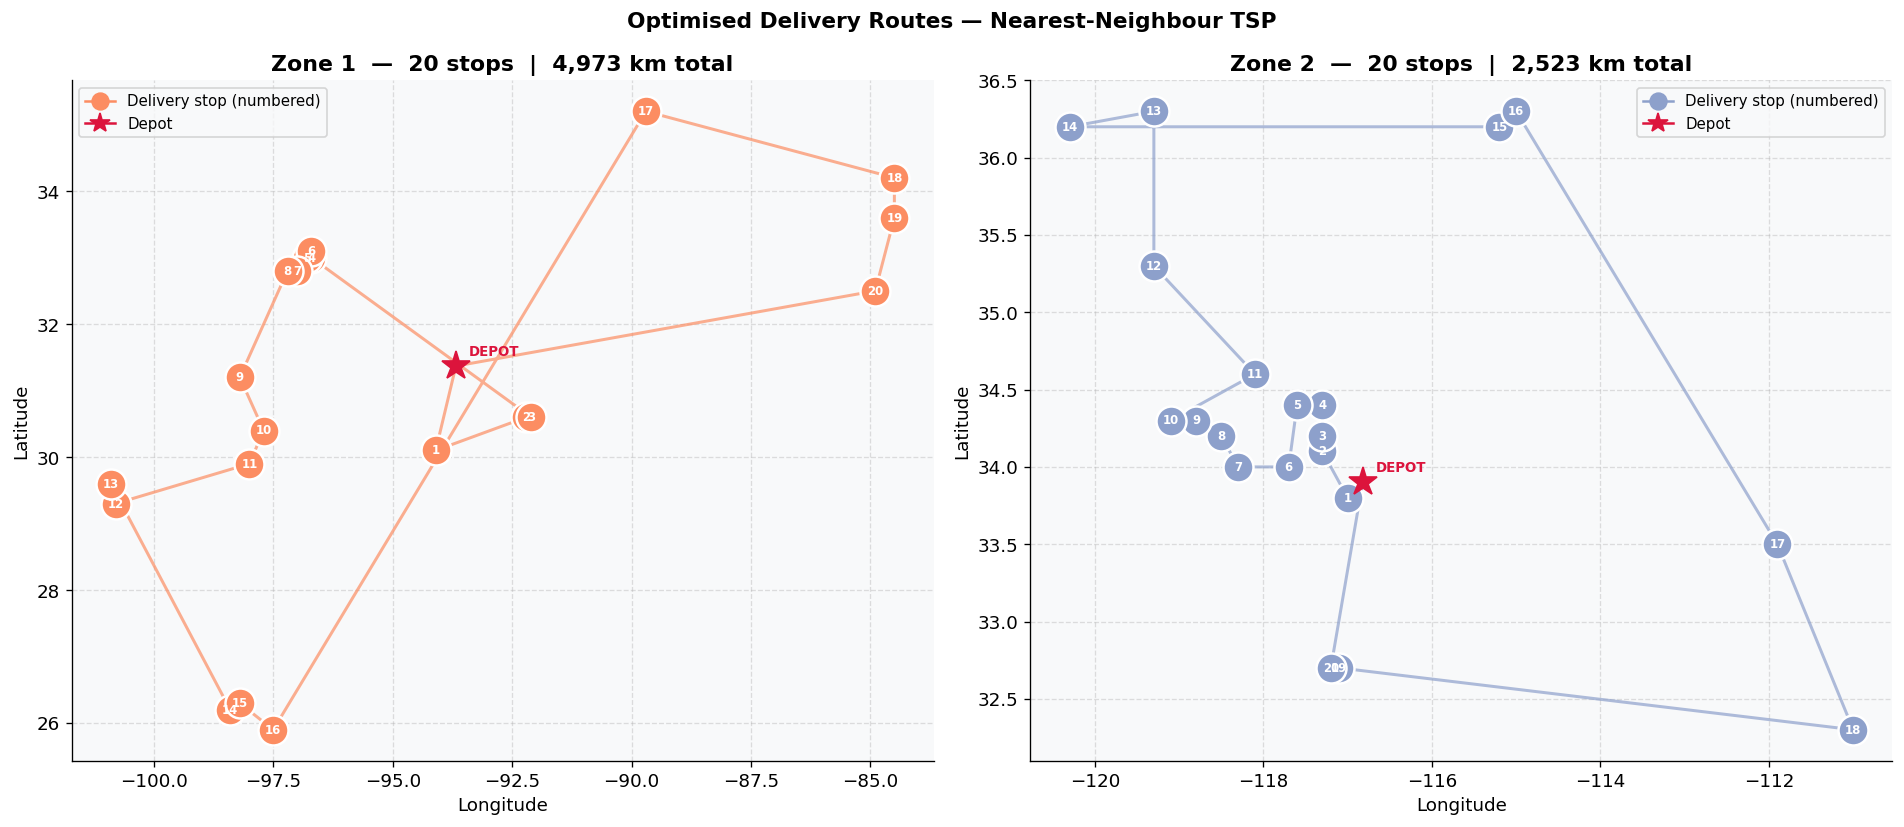

In [48]:
# ── Visualise optimised routes — top 2 zones by stop count ────────────────
# Numbered markers show the visiting order. The red star is the depot.
# Lines connect stops in the order the driver should visit them.

top2 = route_df['n_stops'].nlargest(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Optimised Delivery Routes — Nearest-Neighbour TSP', fontweight='bold', fontsize=13)

for ax, cid in zip(axes, top2):
    info  = cluster_routes[cid]
    depot = info['depot']
    route = info['route']

    full_path_lat = [depot[0]] + [s[0] for s in route] + [depot[0]]
    full_path_lon = [depot[1]] + [s[1] for s in route] + [depot[1]]

    zone_color = PALETTE[cid % len(PALETTE)]

    # Draw route line
    ax.plot(full_path_lon, full_path_lat, '-',
            color=zone_color, linewidth=1.8, alpha=0.7, zorder=2)

    # Draw delivery stop circles with stop number
    for i, (lat, lon) in enumerate(route, start=1):
        ax.plot(lon, lat, 'o', color=zone_color, markersize=18,
                markeredgecolor='white', markeredgewidth=1.5, zorder=3)
        ax.text(lon, lat, str(i), ha='center', va='center',
                fontsize=7, fontweight='bold', color='white', zorder=4)

    # Depot star
    ax.plot(depot[1], depot[0], '*', color='crimson',
            markersize=18, zorder=6)
    ax.annotate('DEPOT', (depot[1], depot[0]),
                textcoords='offset points', xytext=(8, 6),
                fontsize=8, fontweight='bold', color='crimson')

    ax.set_title(f'Zone {cid}  —  {info["n_stops"]} stops  |  {info["total_km"]:,.0f} km total',
                 fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    stop_patch  = mlines.Line2D([], [], marker='o', color=zone_color, markersize=10,
                                label='Delivery stop (numbered)')
    depot_patch = mlines.Line2D([], [], marker='*', color='crimson', markersize=12,
                                label='Depot')
    ax.legend(handles=[stop_patch, depot_patch], fontsize=9)

plt.tight_layout()
plt.show()


Zone 0 — Route Comparison
  Random ordering  :      292.1 km
  Optimised route  :      271.0 km
  Distance saved   :       21.1 km  (7.2% reduction)


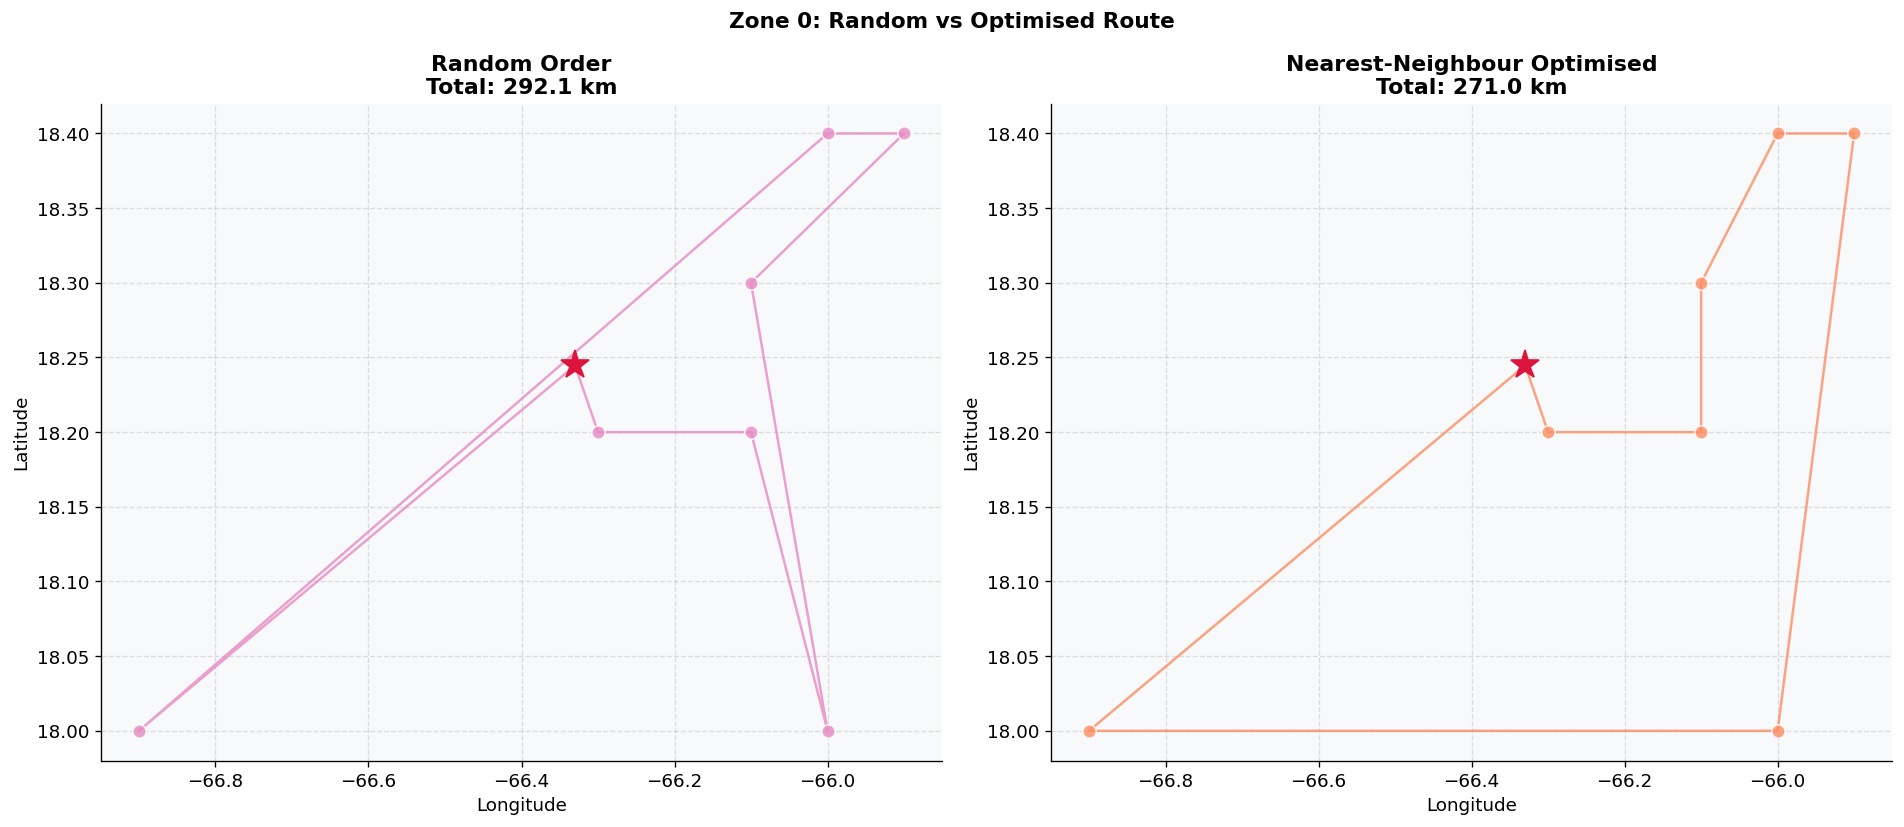

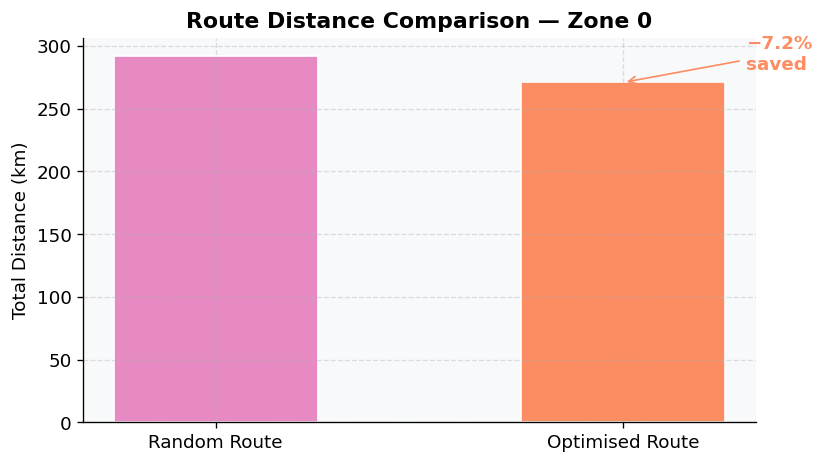

In [49]:
# ── Optimised vs Random route comparison ──────────────────────────────────
# To demonstrate the value of optimization, we compare the nearest-neighbour
# route against a completely random stop ordering for Zone 0.

np.random.seed(42)
cid_demo  = 0
demo      = cluster_routes[cid_demo]
depot     = demo['depot']
stops     = demo['route']

# Random ordering
random_stops = [stops[i] for i in np.random.permutation(len(stops))]
random_dist  = sum(
    haversine(*a, *b)
    for a, b in zip([depot] + random_stops, random_stops + [depot])
)

opt_dist   = demo['total_km']
saved_km   = random_dist - opt_dist
saved_pct  = saved_km / random_dist * 100

print(f'Zone {cid_demo} — Route Comparison')
print(f'  Random ordering  : {random_dist:>10,.1f} km')
print(f'  Optimised route  : {opt_dist:>10,.1f} km')
print(f'  Distance saved   : {saved_km:>10,.1f} km  ({saved_pct:.1f}% reduction)')

# Side-by-side visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Zone {cid_demo}: Random vs Optimised Route', fontweight='bold', fontsize=13)

for ax, order, title, dist, col in zip(
    axes,
    [random_stops, stops],
    ['Random Order', 'Nearest-Neighbour Optimised'],
    [random_dist, opt_dist],
    [PALETTE[3], PALETTE[1]]
):
    path_lat = [depot[0]] + [s[0] for s in order] + [depot[0]]
    path_lon = [depot[1]] + [s[1] for s in order] + [depot[1]]
    ax.plot(path_lon, path_lat, '-o', color=col, linewidth=1.5, markersize=8,
            markeredgecolor='white', alpha=0.8)
    ax.plot(depot[1], depot[0], '*', color='crimson', markersize=18, zorder=5)
    ax.set_title(f'{title}\nTotal: {dist:,.1f} km', fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

# Bar comparison
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Random Route', 'Optimised Route'], [random_dist, opt_dist],
       color=[PALETTE[3], PALETTE[1]], edgecolor='white', width=0.5)
ax.set_ylabel('Total Distance (km)')
ax.set_title(f'Route Distance Comparison — Zone {cid_demo}', fontweight='bold')
ax.annotate(f'−{saved_pct:.1f}%\nsaved',
            xy=(1, opt_dist), xytext=(1.3, (random_dist + opt_dist) / 2),
            fontsize=11, fontweight='bold', color=PALETTE[1],
            arrowprops=dict(arrowstyle='->', color=PALETTE[1]))
plt.tight_layout()
plt.show()


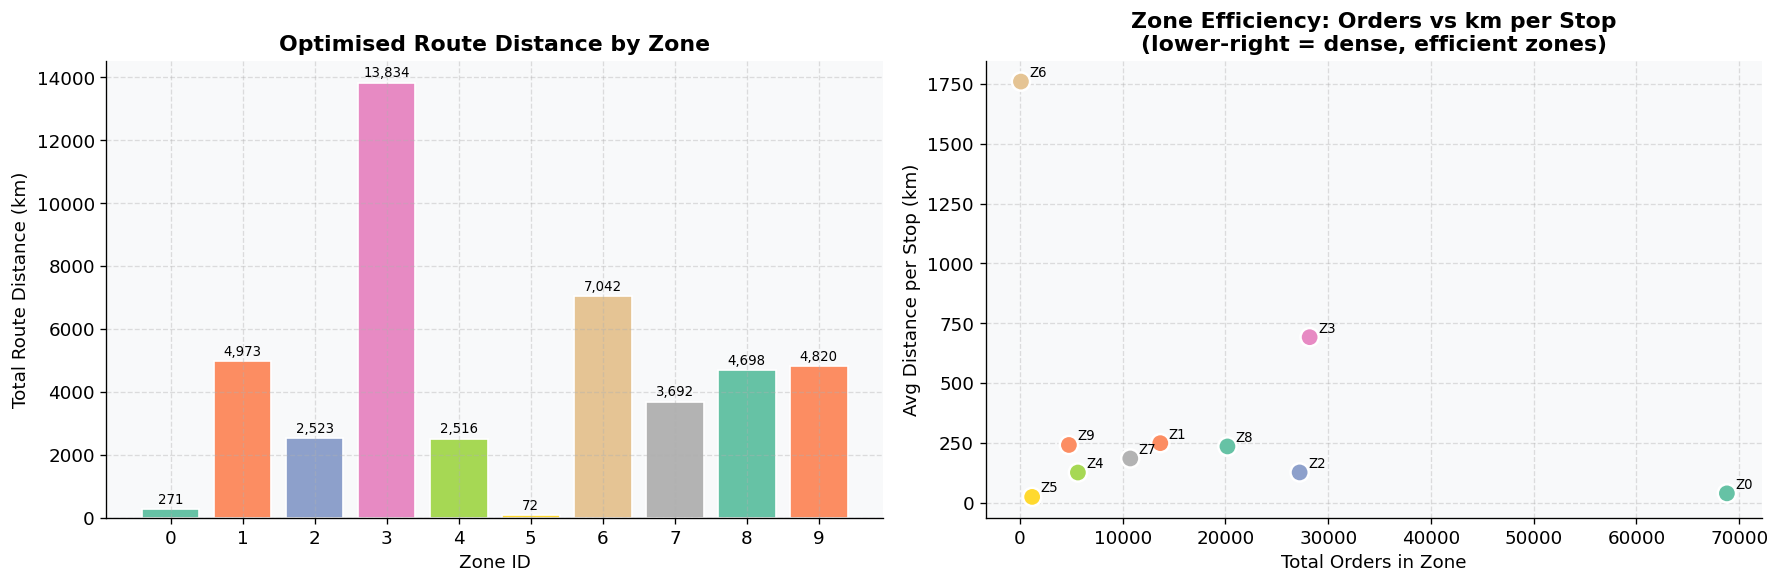

In [50]:
# ── All-zones route distance summary ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar: total km per zone
colors_z = [PALETTE[i % len(PALETTE)] for i in route_df.index]
bars = axes[0].bar(route_df.index.astype(str), route_df['total_km'],
                   color=colors_z, edgecolor='white')
for bar, km in zip(bars, route_df['total_km']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80,
                 f'{km:,.0f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xlabel('Zone ID')
axes[0].set_ylabel('Total Route Distance (km)')
axes[0].set_title('Optimised Route Distance by Zone', fontweight='bold')

# Scatter: km/stop vs n_orders in zone
zone_orders_count = geo.groupby('cluster').size().rename('n_orders')
route_df['n_orders'] = zone_orders_count
axes[1].scatter(route_df['n_orders'], route_df['km_per_stop'],
                c=colors_z, s=120, edgecolors='white', linewidths=1.5, zorder=3)
for _, row in route_df.iterrows():
    axes[1].annotate(f"Z{int(row.name)}",
                     (row['n_orders'], row['km_per_stop']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].set_xlabel('Total Orders in Zone')
axes[1].set_ylabel('Avg Distance per Stop (km)')
axes[1].set_title('Zone Efficiency: Orders vs km per Stop\n'
                  '(lower-right = dense, efficient zones)', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 6. Priority Routing — ML Risk-Weighted Delivery Map

Now we combine the **ML risk scores** from Section 4 with the **geographic zones**
from Section 3 to build a **priority delivery map** — highlighting which areas
need the most urgent attention.

### Business logic
- Orders with predicted risk > 0.70 → **Priority Tier 1** (dispatch first, premium carrier)
- Orders with predicted risk 0.40–0.70 → **Priority Tier 2** (standard express)
- Orders with predicted risk < 0.40 → **Priority Tier 3** (standard shipping)


In [51]:
# ── Score all geo records using best ML model ─────────────────────────────
# ROOT CAUSE FIX: The encoded columns (Shipping Mode_enc, Market_enc,
# Customer Segment_enc) were created on model_df — they do not exist in df.
# Solution: pull the raw NUM_FEATURES from df using geo.index, then
# re-encode the CAT_FEATURES on the fly from df directly.

# Step 1: Start from the geo rows — lat, lon, cluster already computed
geo_model = geo[["Latitude", "Longitude", "cluster"]].copy()

# Step 2: Join the numeric features from df (these exist in df without any encoding)
geo_model = geo_model.join(df.loc[geo.index, NUM_FEATURES], how="left")

# Step 3: Re-encode the categorical features using the same LabelEncoders
# that were fitted during model training (stored in le_encoders dict)
for col in CAT_FEATURES:
    geo_model[col + "_enc"] = le_encoders[col].transform(
        df.loc[geo.index, col].astype(str)
    )

# Step 4: Drop any rows that still have NaN in required feature columns
geo_model = geo_model.dropna(subset=FEATURE_COLS)

# Step 5: Predict late-delivery probability for every geo-tagged order
geo_model["risk_score"] = best_model.predict_proba(
    geo_model[FEATURE_COLS]
)[: , 1]

# Assign priority tier based on risk score threshold
geo_model["priority"] = pd.cut(
    geo_model["risk_score"],
    bins=[0, 0.40, 0.70, 1.0],
    labels=["Tier 3 (Low)", "Tier 2 (Medium)", "Tier 1 (High)"]
)

print("Risk score distribution:")
print(geo_model["risk_score"].describe().round(3))
print()
print("Orders by Priority Tier:")
tier_counts = geo_model["priority"].value_counts().sort_index()
for tier, cnt in tier_counts.items():
    pct = cnt / len(geo_model) * 100
    print(f"  {tier:22s}: {cnt:,}  ({pct:.1f}%)")


Risk score distribution:
count    180519.000
mean          0.548
std           0.228
min           0.264
25%           0.377
50%           0.392
75%           0.767
max           0.981
Name: risk_score, dtype: float64

Orders by Priority Tier:
  Tier 3 (Low)          : 99,563  (55.2%)
  Tier 2 (Medium)       : 18,029  (10.0%)
  Tier 1 (High)         : 62,927  (34.9%)


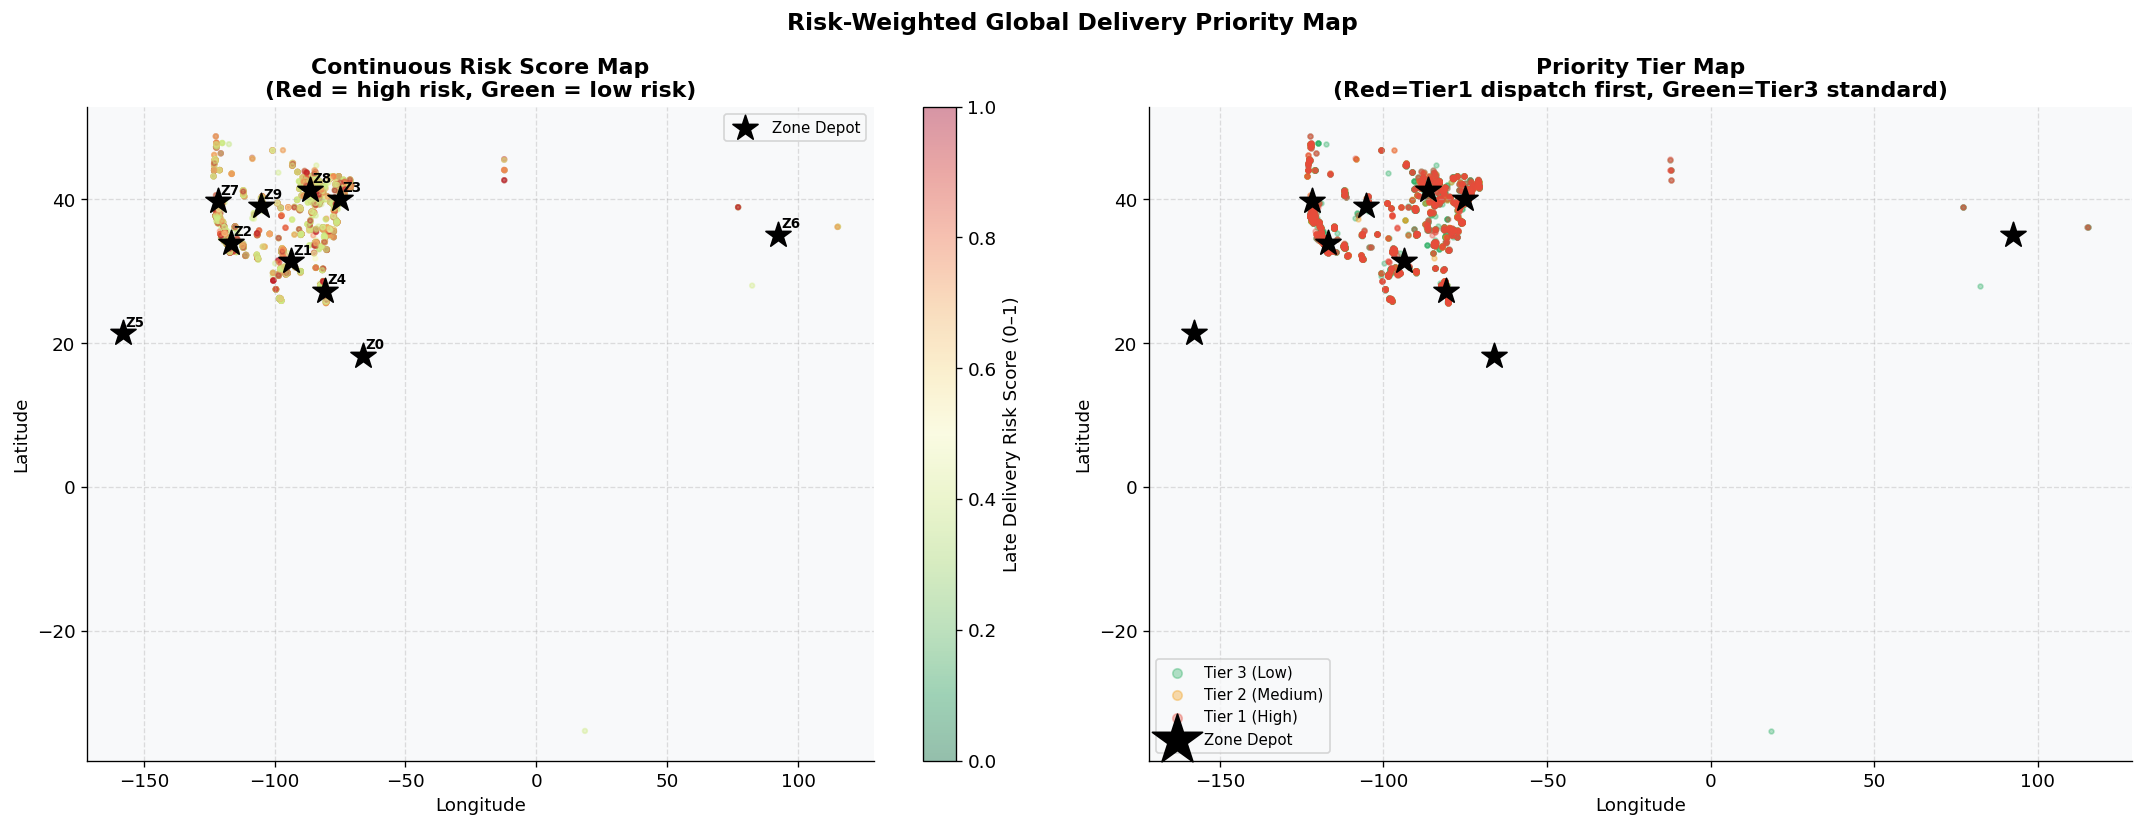

In [52]:
# ── Priority delivery map ─────────────────────────────────────────────────

tier_colors = {
    'Tier 1 (High)'  : '#e74c3c',   # red
    'Tier 2 (Medium)': '#f39c12',   # orange
    'Tier 3 (Low)'   : '#27ae60',   # green
}
sample_r = geo_model.sample(min(12000, len(geo_model)), random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Continuous risk score map ---
sc = axes[0].scatter(
    sample_r['Longitude'], sample_r['Latitude'],
    c=sample_r['risk_score'], cmap='RdYlGn_r',
    alpha=0.4, s=8, vmin=0, vmax=1
)
axes[0].scatter(cluster_centers[:, 1], cluster_centers[:, 0],
                c='black', s=250, marker='*', zorder=5, label='Zone Depot')
for i, c in enumerate(cluster_centers):
    axes[0].annotate(f'Z{i}', (c[1]+1, c[0]+1), fontsize=8, fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='Late Delivery Risk Score (0–1)')
axes[0].set_title('Continuous Risk Score Map\n(Red = high risk, Green = low risk)',
                  fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=9)

# --- Tier-coded map ---
for tier, grp in sample_r.groupby('priority', observed=True):
    axes[1].scatter(grp['Longitude'], grp['Latitude'],
                    c=tier_colors[tier], label=tier,
                    alpha=0.35, s=8)
axes[1].scatter(cluster_centers[:, 1], cluster_centers[:, 0],
                c='black', s=250, marker='*', zorder=5, label='Zone Depot')
axes[1].set_title('Priority Tier Map\n(Red=Tier1 dispatch first, Green=Tier3 standard)',
                  fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle('Risk-Weighted Global Delivery Priority Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


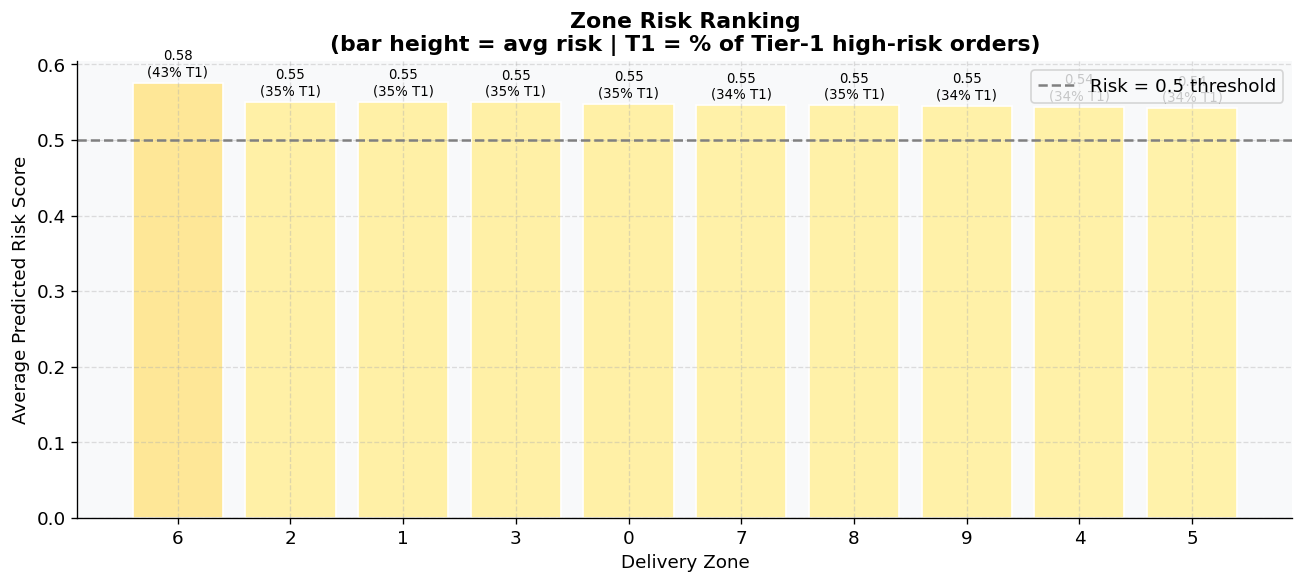

Zone risk summary:


,Avg Risk Score,Tier-1 Orders,Total Orders,Tier-1 %
cluster,,,,
6,0.576049,41,96,42.708333
2,0.550491,9589,27223,35.223892
1,0.550251,4825,13662,35.316937
3,0.549910,9922,28198,35.186893
0,0.548067,23934,68812,34.781724
7,0.546170,3674,10739,34.211752
8,0.546055,6997,20196,34.645474
9,0.545377,1626,4765,34.123820
4,0.544264,1919,5641,34.018791


In [53]:
# ── Zone-level risk summary table ─────────────────────────────────────────

zone_risk = (
    geo_model.groupby('cluster')
    .agg(
        avg_risk        = ('risk_score', 'mean'),
        tier1_orders    = ('risk_score', lambda x: (x > 0.70).sum()),
        total_orders    = ('risk_score', 'count')
    )
    .assign(tier1_pct = lambda x: x['tier1_orders'] / x['total_orders'] * 100)
    .sort_values('avg_risk', ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = plt.cm.RdYlGn_r(zone_risk['avg_risk'].values)
bars = ax.bar(zone_risk.index.astype(str), zone_risk['avg_risk'],
              color=bar_colors, edgecolor='white')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1.5, label='Risk = 0.5 threshold')
for bar, (_, row) in zip(bars, zone_risk.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{row["avg_risk"]:.2f}\n({row["tier1_pct"]:.0f}% T1)',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Delivery Zone')
ax.set_ylabel('Average Predicted Risk Score')
ax.set_title('Zone Risk Ranking\n(bar height = avg risk | T1 = % of Tier-1 high-risk orders)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Zone risk summary:')
display(zone_risk.rename(columns={
    'avg_risk':'Avg Risk Score',
    'tier1_orders':'Tier-1 Orders',
    'total_orders':'Total Orders',
    'tier1_pct':'Tier-1 %'
}))


---
## 7. Business Insights & Recommendations

In [54]:
# ── Auto-generated executive summary ─────────────────────────────────────
worst_mode    = ship_mode['late_pct'].idxmax()
best_mode     = ship_mode['late_pct'].idxmin()
worst_zone    = zone_risk['avg_risk'].idxmax()
best_zone     = zone_risk['avg_risk'].idxmin()
top_feature   = pd.Series(rf.feature_importances_, index=FEATURE_COLS).idxmax()

print('=' * 70)
print('  📦  DELIVERY ROUTE OPTIMIZATION — EXECUTIVE SUMMARY')
print('=' * 70)
print(f"""
DATASET
  Orders analysed  : {len(df):,}
  Date range       : {df['order_date'].min().date()} → {df['order_date'].max().date()}
  Markets          : {', '.join(sorted(df['Market'].dropna().unique()))}
  Shipping modes   : {', '.join(sorted(df['Shipping Mode'].dropna().unique()))}

DELIVERY PERFORMANCE
  Overall late-delivery risk rate  : {late_rate:.1f}%
  Avg shipping delay beyond SLA    : {df['ship_delay'].mean():.2f} days
  Worst shipping mode (late rate)  : {worst_mode}  ({ship_mode.loc[worst_mode,'late_pct']:.1f}%)
  Best  shipping mode (late rate)  : {best_mode}  ({ship_mode.loc[best_mode,'late_pct']:.1f}%)

DELIVERY ZONE CLUSTERING (k={N_CLUSTERS})
  Highest-risk zone  : Zone {worst_zone}  (avg risk score {zone_risk.loc[worst_zone,'avg_risk']:.2f})
  Lowest-risk zone   : Zone {best_zone}  (avg risk score {zone_risk.loc[best_zone,'avg_risk']:.2f})

PREDICTIVE MODEL
  Best classifier    : {best_name}  (AUC-ROC = {results[best_name]['auc']:.4f})
  Top risk driver    : {top_feature}

ROUTE OPTIMISATION
  Total combined distance  : {route_df['total_km'].sum():,.0f} km across {N_CLUSTERS} zones
  Demo zone savings        : {saved_pct:.1f}% distance reduction vs random ordering
""")

print('=' * 70)
print('  💡  RECOMMENDATIONS')
print('=' * 70)
print("""
1. SHIPPING MODE STRATEGY
   → Migrate high-value orders in high-risk zones to First Class or Same Day.
   → Audit Standard Class carriers — they account for the majority of late orders.
   → Negotiate SLA penalties with carriers exceeding 50% late rate.

2. ZONE-BASED DISPATCHING
   → Implement the 10 delivery zones as operational territories with dedicated
     carrier teams and zone-specific KPIs.
   → Dispatch drivers using the nearest-neighbour route sequences from Section 5.
   → For Tier-1 (risk > 0.70) orders, trigger same-day re-routing.

3. REAL-TIME ML RISK SCORING
   → Deploy the Random Forest model as a microservice at order placement.
   → Flag orders with predicted risk > 0.70 for manual review before dispatch.
   → Send automated customer alerts ('Your order may experience delay') proactively.

4. SEASONAL CAPACITY PLANNING
   → Use the monthly trend chart to pre-position warehouse stock 4 weeks ahead
     of historically high-volume months to prevent carrier overload.

5. PRODUCTION-GRADE ROUTE OPTIMISATION
   → Replace nearest-neighbour heuristic with Google OR-Tools VRPTW solver for
     multi-vehicle, time-window, and capacity-constrained routing.
   → Integrate live traffic APIs (Google Maps Platform) to adjust routes in real time.
   → A/B test optimised routes vs current process to measure real-world fuel/time savings.
""")


  📦  DELIVERY ROUTE OPTIMIZATION — EXECUTIVE SUMMARY

DATASET
  Orders analysed  : 180,519
  Date range       : 2015-01-01 → 2018-01-31
  Markets          : Africa, Europe, LATAM, Pacific Asia, USCA
  Shipping modes   : First Class, Same Day, Second Class, Standard Class

DELIVERY PERFORMANCE
  Overall late-delivery risk rate  : 54.8%
  Avg shipping delay beyond SLA    : 0.93 days
  Worst shipping mode (late rate)  : First Class  (95.3%)
  Best  shipping mode (late rate)  : Standard Class  (38.1%)

DELIVERY ZONE CLUSTERING (k=10)
  Highest-risk zone  : Zone 6  (avg risk score 0.58)
  Lowest-risk zone   : Zone 5  (avg risk score 0.54)

PREDICTIVE MODEL
  Best classifier    : Random Forest  (AUC-ROC = 0.7349)
  Top risk driver    : Days for shipment (scheduled)

ROUTE OPTIMISATION
  Total combined distance  : 44,440 km across 10 zones
  Demo zone savings        : 7.2% distance reduction vs random ordering

  💡  RECOMMENDATIONS

1. SHIPPING MODE STRATEGY
   → Migrate high-value orders in 

---
### 📖 References & Further Reading
- Konstantakopoulos, G.D. et al. (2020). *DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS*. Mendeley Data.
- Applegate, D. et al. (2006). *The Travelling Salesman Problem*. Princeton University Press.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.

---
*Notebook complete. Place `DataCoSupplyChainDataset.csv` in the same directory and run all cells top-to-bottom.*
